In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
np.random.seed(42)
data = np.random.normal(50, 10, 100)   # Normal distribution data
outliers = [10, 120, 150]              # Extreme outliers

data = np.concatenate([data, outliers])

df = pd.DataFrame({'value': data})

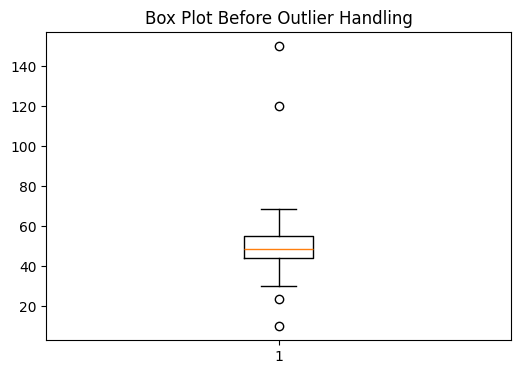

In [3]:
plt.figure(figsize=(6, 4))
plt.boxplot(df['value'])
plt.title("Box Plot Before Outlier Handling")
plt.show()

In [4]:
Q1 = df['value'].quantile(0.25)
Q3 = df['value'].quantile(0.75)
IQR = Q3 - Q1

In [5]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Q1: 43.98827348925899
Q3: 55.04990793062294
IQR: 11.061634441363957
Lower Bound: 27.39582182721305
Upper Bound: 71.64235959266888


In [6]:
outliers_df = df[(df['value'] < lower_bound) | (df['value'] > upper_bound)]
print("\nIdentified Outliers:")
print(outliers_df)


Identified Outliers:
          value
74    23.802549
100   10.000000
101  120.000000
102  150.000000


In [7]:
df.loc[df['value'] < lower_bound, 'value'] = lower_bound
df.loc[df['value'] > upper_bound, 'value'] = upper_bound

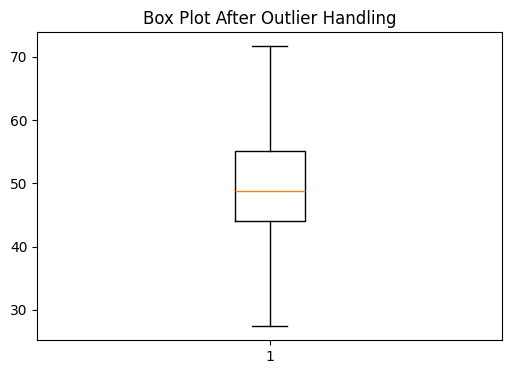

In [8]:
plt.figure(figsize=(6, 4))
plt.boxplot(df['value'])
plt.title("Box Plot After Outlier Handling")
plt.show()